In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import os
# from cgp.nn import UModel
import yaml
import mdtraj as md
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker

plt.style.use('rotskoff')
rotskoff_cmap = mpl.colors.LinearSegmentedColormap.from_list("mycmap", ['#1B346C','#01ABE9','#F1F8F1','#F54B1A'])
rotskoff_cmap_2 = mpl.colors.LinearSegmentedColormap.from_list("mycmap", ['#FFFFFF', '#820000'])
PATH = "/global/common/software/nersc9/texlive/2024/bin/x86_64-linux"
import os
os.environ["PATH"] += ":" + PATH
import subprocess
subprocess.run(['which', 'tex'], stdout=subprocess.PIPE)

import torch

In [2]:
# rsync -azP --include="*/" rotskoffh100:/data2/scratch/group_scratch/cg/080725ScoreMatch/cg_sim_bba_300/ cg_sim_bba_300/

In [3]:
def rmsd_np(P, Q):
    """
    Compute RMSD per frame using Theobald's method (no explicit alignment).
    
    P: (n_frames, n_atoms, 3)
    Q: (n_frames, n_atoms, 3)

    Returns:
        rmsd_per_frame: (n_frames,)
    """
    # Q = np.repeat(Q, P.shape[0], axis=0)  # Ensure Q has the same number of frames as P
    P = torch.tensor(P, dtype=torch.float32)
    Q = torch.tensor(Q, dtype=torch.float32)

    # Center both structures
    P_centered = P - P.mean(dim=1, keepdim=True)
    Q_centered = Q - Q.mean(dim=1, keepdim=True)

    # Compute covariance matrix
    C = torch.matmul(P_centered.transpose(1, 2), Q_centered)  # (n_frames, 3, 3)

    # SVD on covariance matrix
    V, S, W = torch.linalg.svd(C)
    det = torch.det(torch.matmul(V, W.transpose(-1, -2)))
    sign_correction = det.sign()
    S_corrected = S.clone()
    S_corrected[:, -1] *= sign_correction  # fix last singular value

    dot = 2 * torch.sum(S_corrected, dim=-1)

    # Compute squared norms
    P_norm_sq = torch.sum(P_centered ** 2, dim=(1, 2))
    Q_norm_sq = torch.sum(Q_centered ** 2, dim=(1, 2))

    # RMSD² = (||P||² + ||Q||² - 2 * sum(S)) / N
    # dot = 2 * torch.sum(S, dim=-1)
    rmsd_sq = (P_norm_sq + Q_norm_sq - dot) / P.shape[1]
    # rmsd_sq = torch.clamp(rmsd_sq, min=0.0)

    return torch.sqrt(rmsd_sq).numpy()

In [4]:
bba_pdb = md.load("/home/scratch/group_scratch/cg/082825ProteinCVSetup/experimental_structures/bba_1fme.pdb")
bba_ca_pdb = bba_pdb.atom_slice(bba_pdb.topology.select("name CA"))
ref_ca_p = bba_ca_pdb.xyz * 10

helix_pdb = md.load("/home/scratch/group_scratch/cg/082825ProteinCVSetup/helix.pdb")
helix_ca_pdb = helix_pdb.atom_slice(helix_pdb.topology.select("name CA"))
helix_ca_p = helix_ca_pdb.xyz * 10

In [5]:
def transform_a(x):
        # x = (1 - x**8) / (1- x**12)
        x = np.log(x + 2)
        return x

def transform_b(x):
        # x = 1 - (1 / (1 + np.exp(3  - (0.75) *  x)))
        x = np.log(x + 1)
        return x

def get_bba_rc(ca_positions, topology=bba_ca_pdb.topology):
    ca_positions = ca_positions[:, topology.select("name CA"), :]
    ref0 = np.repeat(ref_ca_p, ca_positions.shape[0], axis=0)
    helix_ref = np.repeat(helix_ca_p, ca_positions.shape[0], axis=0)
    a = transform_a(rmsd_np(ca_positions[:, 15:26, :], helix_ref[:, 15:26, :]))
    b = transform_b(rmsd_np(ca_positions[:, 3:15, :], ref0[:, 3:15, :]))
    return np.concatenate([a[:, None], b[:, None]], axis=1)

# CG Map and Features

In [6]:
bias_folder = "bias_force_bba_092425"
pdb = md.load(f"/home/scratch/group_scratch/cg/082525CGSim/{bias_folder}/bba.pdb")
backbone = pdb.top.select("name CA or name N or name C")
cg = pdb.atom_slice(backbone)
cg_topology = cg.topology


# FG Trajectory Analaysis

In [7]:
# CG Simulations initialized to starting_positions
bba_ca_p = np.load("/home/scratch/group_scratch/cg/082825ProteinCVSetup/bba_ca_coords.npy")[::10]
fg_cv = get_bba_rc(bba_ca_p)

Text(0, 0.5, 'TIC 1')

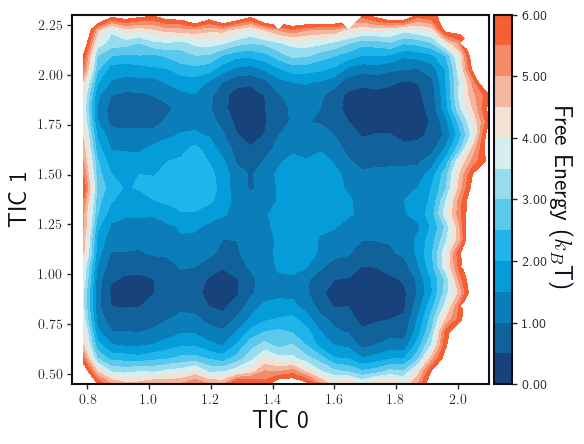

In [8]:
init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(fg_cv[:, 0], 
                                                      fg_cv[:, 1],
                                                        bins=30)


init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
init_z = init_z.T
init_z_density = init_z/float(init_z.sum())
init_free_energy = np.inf * np.ones(shape=init_z.shape)

nonzero = init_z_density.nonzero()
init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
init_free_energy = init_free_energy - init_free_energy.min()

vmax = 6
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax * 2 + 1), cmap=rotskoff_cmap)
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax * 2 + 1), pad=0.01)
cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
plt.xlim(0.75, 2.1)
plt.ylim(0.45, 2.3)

plt.xlabel("TIC 0")
plt.ylabel("TIC 1")
# # plt.savefig("figures/trpcage/trpcage_schnet_free_energy.pdf", dpi=300)

In [9]:
pdb = md.load(f"/home/scratch/group_scratch/cg/082525CGSim/{bias_folder}/bba.pdb")
cg = pdb.atom_slice(pdb.top.select("name CA or name C or name N"))

# Analyzing CG Simulations

In [10]:
def get_checkpoints(folder, sim_type="duplicate", get_centers=False):
    chk_freq = yaml.load(open(f"{folder[0]}/config.yaml"), Loader=yaml.FullLoader)["global_args"]["chk_freq"]
    if get_centers:
        if sim_type == "restart" or sim_type == "duplicate":
            centers = torch.jit.load(yaml.load(open(f"{folder[0]}/config.yaml"), 
                                    Loader=yaml.FullLoader)["global_args"]["bias_force"]).centers.detach().numpy()
        else: 
            centers = np.concatenate([torch.jit.load(yaml.load(open(f"{f}/config.yaml"), 
                                                Loader=yaml.FullLoader)["global_args"]["bias_force"]).centers.detach().numpy()
                            for f in folder])
        batch_size = centers.shape[0]
    else:
        batch_size = yaml.load(open(f"{folder[0]}/config.yaml"), 
                                    Loader=yaml.FullLoader)["global_args"]["batch_size"]
        if sim_type == "batched":
            batch_size = batch_size * len(folder)
        centers = None

    
    if chk_freq == 100:
        burnin = 100
        max = 999
    else:
        burnin = 10
        max = 99
    # burnin = 0

    checkpoints = [[f"{folder}/{x}" for x in os.listdir(folder) if "hdf5" in x] for folder in folder]
    checkpoints = [sorted(x, key=lambda x: int(x.split("_")[-1].split(".")[0])) for x in checkpoints]
    # min = np.min(np.array([len(x) for x in checkpoints]))
    if sim_type == "restart":
        min = len(checkpoints[-1])
        checkpoints[0] = checkpoints[0][burnin:]
        checkpoints[-1] = checkpoints[-1][:min - 1]
        checkpoints = np.concatenate([np.concatenate([h5py.File(y, "r")["positions"][::10, :, :, :] for y in x], 
                                                    axis=0) for x in checkpoints], axis=0)
    if sim_type == "duplicate":
        min = np.min(np.array([len(x) for x in checkpoints])) - 1
        if min <= burnin:
            if min == 1:
                burnin = 0
            else:
                burnin = 1
        checkpoints = [x[burnin:min] for x in checkpoints]
        checkpoints = np.concatenate([np.concatenate([h5py.File(y, "r")["positions"][::10, :, :, :] for y in x], 
                                                    axis=0) for x in checkpoints], axis=0)
    elif sim_type == "batched":
        min = np.min(np.array([len(x) for x in checkpoints])) - 1
        if min <= burnin * 2:
            if min <= 5:
                burnin = 0
            else:
                burnin = 5
        if min == max:
            end = min + 1
        else:
            end = min
        # burnin = 0
        print(min, max, burnin)
        checkpoints = [x[burnin:end] for x in checkpoints]
        checkpoints = np.concatenate([np.concatenate([h5py.File(y, "r")["positions"][::10, :, :, :] for y in x], 
                                                    axis=0) for x in checkpoints], axis=1)


    print(checkpoints.shape)


    grouped = np.transpose(checkpoints, (0, 1, 2, 3))
    cg_sim = grouped.reshape(grouped.shape[0], -1, grouped.shape[2], grouped.shape[3])
    print(np.where(np.isnan(cg_sim).any(axis=(0, 2, 3))))

    cg_sim = cg_sim.reshape(-1, cg.n_atoms, 3)

    print(cg_sim.shape)

    cg_sim = cg_sim.reshape(-1, cg.n_atoms, 3)
    # cg_sim = cg_sim[~np.isnan(cg_sim).any(axis=(1, 2)), :, :]
    print(cg_sim.shape)
    return cg_sim, centers, batch_size

In [11]:
start_positions = np.load(f"/home/scratch/group_scratch/cg/082525CGSim/{bias_folder}/start_positions.npy")
start_cv = get_bba_rc(start_positions, topology=pdb.topology)

In [15]:
# folder = ["cg_sim_no_bias_bba_300/mace/version_1"]
# cg_sim, centers, batch_size = get_checkpoints(folder, sim_type="batched", get_centers=False)

# folder = ["cg_sim_bba_300/esen/version_1"]
# cg_sim, centers, batch_size = get_checkpoints(folder, sim_type="batched", get_centers=False)

# folder = ["cg_sim_no_bias_bba_300/mace/version_2"]
# cg_sim, centers, batch_size = get_checkpoints(folder, sim_type="batched", get_centers=False)

# folder = ["cg_sim_bba_300/mace/version_7"]
# cg_sim, centers, batch_size = get_checkpoints(folder, sim_type="batched", get_centers=False)

folder = ["cg_sim_bba_uncapped/mace/version_2"]
cg_sim, centers, batch_size = get_checkpoints(folder, sim_type="batched", get_centers=False)

88 99 10
(7800, 100, 84, 3)
(array([], dtype=int64),)
(780000, 84, 3)
(780000, 84, 3)


In [16]:
cv = get_bba_rc(cg_sim, topology = cg.topology)

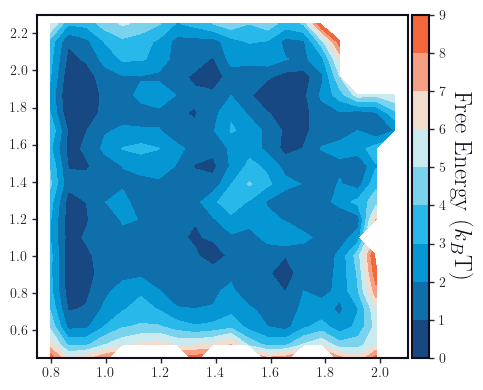

In [17]:
init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(cv[:, 0], 
                                                      cv[:, 1],
                                                        bins=20)


init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
init_z = init_z.T
init_z_density = init_z/float(init_z.sum())
init_free_energy = np.inf * np.ones(shape=init_z.shape)

nonzero = init_z_density.nonzero()
init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
init_free_energy = init_free_energy - init_free_energy.min()

vmax = 9

plt.figure(figsize=(5, 4))
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax + 1), cmap=rotskoff_cmap)
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax + 1), pad=0.01)
cbar.set_label(r"$\textrm{Free Energy (}k_B \textrm{T)}$", rotation=270, labelpad=20)
cbar.set_ticks(np.arange(0, vmax + 1, 1))
# if centers is not None:
#     plt.scatter(centers[:, 0], centers[:, 1], color='black', s=10, marker="x", label="Centers")
# # plt.scatter(a, b)
# plt.scatter(start_cv[:, 0], start_cv[:, 1], color='red', s=10)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.2))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.2))

# plt.xlabel("TIC 0")
# plt.ylabel("TIC 1")
plt.xlim(0.75, 2.1)
plt.ylim(0.45, 2.3)
# # plt.savefig("figures/trpcage/trpcage_schnet_free_energy.pdf", dpi=300)
plt.tight_layout()

In [18]:
# # starting = np.load(yaml.load(open(f"{folder[0]}/config.yaml"), Loader=yaml.FullLoader)["global_args"]["start_indices"])
# for index in range(batch_size):
#     vmax = 7
#     steps = 8
#     plt.contourf(init_rc1, init_rc2, init_free_energy,
#                     levels=np.linspace(0, vmax, steps), cmap=rotskoff_cmap)
#     cbar = plt.colorbar(boundaries=np.linspace(0, vmax, steps), pad=0.01)
#     cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
#     #87th is misfolded
#     # plt.scatter(tica[index::100, 0], tica[index::100, 1], color='blue', s=10, label="Starting Configurations")
#     index_cv = cv[index::batch_size]

#     # plt.legend()
#     plt.title(index)
#     plt.plot(index_cv[:, 0], index_cv[:, 1], color='red')
#     plt.scatter(index_cv[-1, 0], index_cv[-1, 1], color='black', s=20, label="End", zorder=10)
#     plt.scatter(start_cv[index, 0], start_cv[index, 1], color='blue', s=20, label="Start", zorder=10)
#     # plt.scatter(centers[index, 0], centers[index, 1], color='green', s=20, label="Center", zorder=10)
#     # plt.scatter(test_tica[index, 0], test_tica[index, 1], color='orange', s=20, label="Test", zorder=10)
#     plt.legend()
#     plt.xlim(0.75, 2.1)
#     plt.ylim(0.45, 2.3)
#     plt.show()

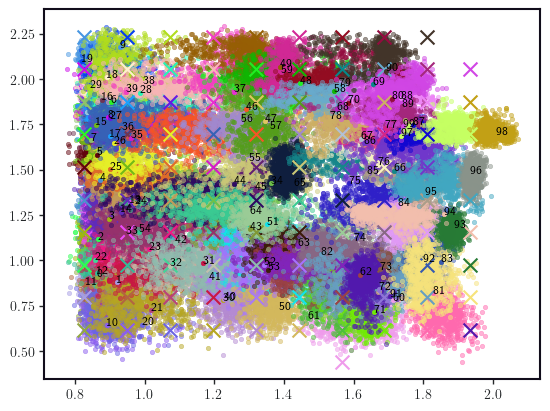

In [19]:
starting = np.load(f"/home/scratch/group_scratch/cg/082525CGSim/{bias_folder}/start_positions.npy")
centers = np.load(f"/home/scratch/group_scratch/cg/082525CGSim/{bias_folder}/centers.npy")
for index in range(batch_size):
    color = np.random.rand(3,)
    index_cv = cv[index::batch_size]
    plt.scatter(index_cv[::10, 0], index_cv[::10, 1], alpha=0.5, color=color, s=10)
    if centers is not None:
        plt.scatter(centers[index, 0], centers[index, 1], color=color, s=100, marker="x", label="Center", zorder=10)
    else:
        plt.scatter(start_cv[index, 0], start_cv[index, 1], color=color, s=100, marker="x", label="Start", zorder=10)
        # plt.text(start_a[index], start_b[index], str(index), fontsize=8, color="black", zorder=11)
    plt.scatter(index_cv[-1, 0], index_cv[-1, 1], color=color, s=10, marker="o", label="Center", zorder=10)
    plt.text(index_cv[-1, 0], index_cv[-1, 1], str(index), fontsize=8, color="black", zorder=11)
    # plt.text(index_a[-1] , index_b[-1], str(index), fontsize=8, color="black", zorder=11)
    # plt.xlim(-1.25, 1)
    # plt.ylim(-1.15, 1.4)

In [20]:
traj = md.Trajectory(cg_sim / 10, cg.topology)
traj.center_coordinates()
traj[54::batch_size * 10].save("test.pdb")

# Analysis

In [21]:
import pymbar
import openmm.unit

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

********* JAX NOT FOUND *********
 PyMBAR can run faster with JAX  
 But will work fine without it   
Either install with pip or conda:
      pip install pybar[jax]     
               OR                
      conda install pymbar       
*********************************


25.0
(52000, 2)


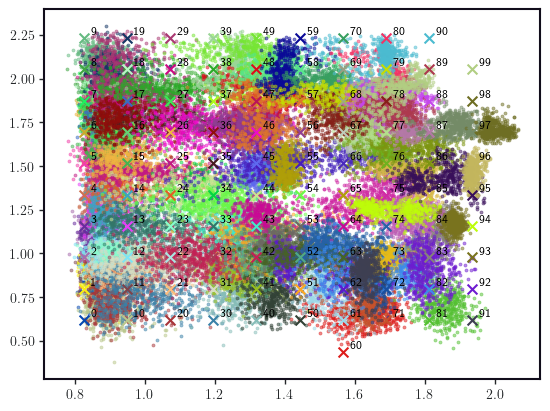

In [29]:
stride = 15
# bias_energies = []
reindexed_tica = []
k = torch.jit.load(f"/home/scratch/group_scratch/cg/082525CGSim/{bias_folder}/bias_force_bba.pt").bias_force
print(k)

for index in range(batch_size):
    index_cv = cv[index::batch_size * stride]
    color = np.random.rand(3,)
    plt.scatter(index_cv[:, 0], index_cv[:, 1], alpha=0.5, color=color, s=5)
    # energy = k * ((index_tica - centers[index, :]) ** 2).sum(axis=1)
    reindexed_tica.append(index_cv)
    if centers is not None:
        plt.scatter(centers[index, 0], centers[index, 1], color=color, s=50, marker="x", label="Center", zorder=10)
        plt.text(centers[index, 0] + 0.02, centers[index, 1] + 0.02, str(index), fontsize=8, color="black")
# plt.scatter(centers[:, 0], centers[:, 1], color='black', label="Centers", zorder=10)
reindexed_tica = np.concatenate(reindexed_tica, axis=0)
print(reindexed_tica.shape)
    

In [30]:
kt_unit = (300 * openmm.unit.kelvin * openmm.unit.BOLTZMANN_CONSTANT_kB * openmm.unit.AVOGADRO_CONSTANT_NA).in_units_of(openmm.unit.kilocalorie_per_mole)
print(kt_unit)

0.5961612775922495 kcal/mol


In [31]:
energy_unit = 1.0 * openmm.unit.kilocalorie_per_mole
kT = (300 * openmm.unit.kelvin * openmm.unit.BOLTZMANN_CONSTANT_kB * openmm.unit.AVOGADRO_CONSTANT_NA).value_in_unit(openmm.unit.kilocalorie_per_mole)
print(kT)
energy_conversion = energy_unit / kt_unit
print(energy_conversion)

0.5961612775922495
1.677398444995886


In [32]:
bias_energies = []
for index in range(batch_size):
    diff = ((reindexed_tica - centers[index, :]) ** 2).sum(axis=-1)
    energy = k * diff
    bias_energies.append(energy)
bias_energies = np.array(bias_energies) / kT

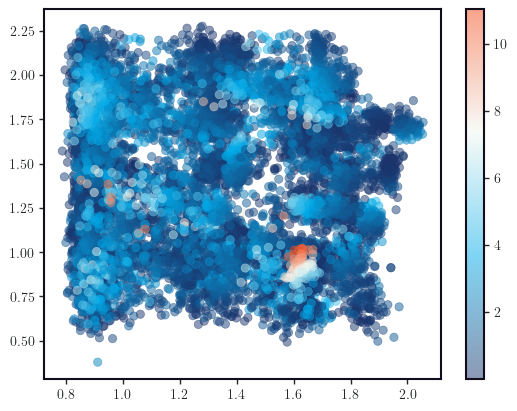

In [33]:
s = 5
points = bias_energies.shape[1] // batch_size
energy = np.concatenate([bias_energies[i][i * points:(i + 1) * points] for i in range(batch_size)])[::s]
plt.scatter(reindexed_tica[::s, 0], reindexed_tica[::s, 1], alpha=0.5, c=energy, cmap=rotskoff_cmap)
plt.colorbar()  # Adjust ticks as needed
# for i in range(100):
#     index = reindexed_tica[i * points:(i + 1) * points, :]
#     energy = bias_energies[i][i * points:(i + 1) * points]
#     scatter = plt.scatter(index[:, 0], index[:, 1], alpha=0.5, c=energy, cmap=rotskoff_cmap)
#     plt.plot(centers[i, 0], centers[i, 1], "o", color="red")
#     plt.colorbar(scatter, ticks=np.linspace(0, 30, 6))  # Adjust ticks as needed
#     plt.xlim(-1.25, 1)
#     plt.ylim(-1.15, 1.4)
#     plt.title(i)
#     plt.show()

In [34]:
# # Calculate N_k such that the sum matches the total number of samples in bias_energies
N_k = np.ones(batch_size, dtype=int) * bias_energies.shape[1] / batch_size
print(N_k)
# print(bias_energies.shape)
# # Initialize MBAR
# mbar = pymbar.MBAR(bias_energies, N_k, verbose=False)

# energies = (mbar.compute_free_energy_differences()['Delta_f'])[0] 
# energies = energies - energies.min()

# # plot centers and energies
# plt.scatter(centers[:, 0], centers[:, 1], c=energies, cmap=rotskoff_cmap, s=900, marker="s")
# plt.colorbar(label="Free Energy ($k_B$T)", pad=0.01)

[520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520.
 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520.
 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520.
 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520.
 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520.
 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520.
 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520. 520.
 520. 520.]


In [35]:
fes = pymbar.FES(
    bias_energies,
    N_k
)

_, x_edges, y_edges = np.histogram2d(reindexed_tica[:, 0], reindexed_tica[:, 1], bins=20)

fes.generate_fes(np.zeros(reindexed_tica.shape[0]), reindexed_tica, fes_type="histogram", histogram_parameters={"bin_edges": [x_edges, y_edges]})


{'timing': 0.5885918389540166}

In [36]:
bin_centers_0 = 0.5 * (x_edges[:-1] + x_edges[1:])
bin_centers_1 = 0.5 * (y_edges[:-1] + y_edges[1:])
bin_centers = np.array(np.meshgrid(bin_centers_0, bin_centers_1)).T.reshape(-1, 2)

width_0 = bin_centers_0[1] - bin_centers_0[0]
width_1 = bin_centers_1[1] - bin_centers_1[0]

centers_to_use = []
center_indices_to_use = []

for i in range(bin_centers.shape[0]):
    bin_center = bin_centers[i]
    x0, x1 = bin_center[0] - width_0 / 2, bin_center[0] + width_0 / 2
    y0, y1 = bin_center[1] - width_1 / 2, bin_center[1] + width_1 / 2
    
    mask = (reindexed_tica[:, 0] >= x0) & (reindexed_tica[:, 0] < x1) & (reindexed_tica[:, 1] >= y0) & (reindexed_tica[:, 1] < y1)
    num_points = np.sum(mask)
    if num_points > 0:
        centers_to_use.append(bin_center)
        center_indices_to_use.append(i)
centers_to_use = np.array(centers_to_use)
center_indices_to_use = np.array(center_indices_to_use)

In [37]:
results = fes.get_fes(centers_to_use, uncertainty_method="analytical")
f = results["f_i"]
f = f - f.min()
print(f.max())

16.64545169114117


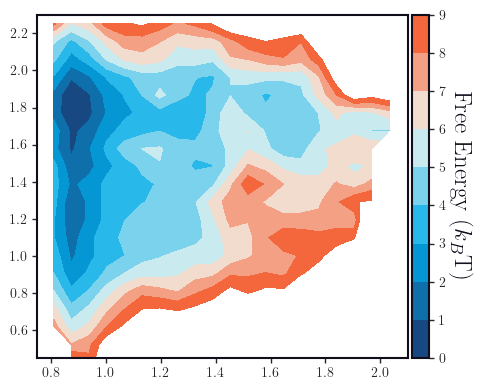

In [38]:
free_energy = np.inf * np.ones(bin_centers.shape[0])
free_energy[center_indices_to_use] = f

plt.figure(figsize=(5, 4))
vmax = 9
plt.contourf(bin_centers_0, bin_centers_1, free_energy.reshape(len(bin_centers_0), len(bin_centers_1)).T,
                levels=np.linspace(0, vmax, vmax + 1), cmap=rotskoff_cmap)
cbar = plt.colorbar(boundaries=np.linspace(0, vmax,vmax + 1), pad=0.01)
cbar.set_label(r"$\textrm{Free Energy (}k_B \textrm{T)}$", rotation=270, labelpad=20)
# only label integer values
cbar.set_ticks(np.arange(0, vmax + 1, 1))
# # plt.scatter(centers[:, 0], centers[:, 1], color='black', s=10, marker="x", label="Centers")
# plt.scatter(starting_tica[:, 0], starting_tica[:, 1], color='red', s=10)
# cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# make X and Y axis ticks every 0.5
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.2))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.2))


# plt.xlabel(r"$\textrm{Native Contacts}$")
# plt.ylabel(r"$\textrm{Dihedral}$")
plt.xlim(0.75, 2.1)
plt.ylim(0.45, 2.3)
plt.tight_layout()
# # plt.savefig("figures/trpcage/trpcage_schnet_free_energy.pdf", dpi=300)

## Uncertainity

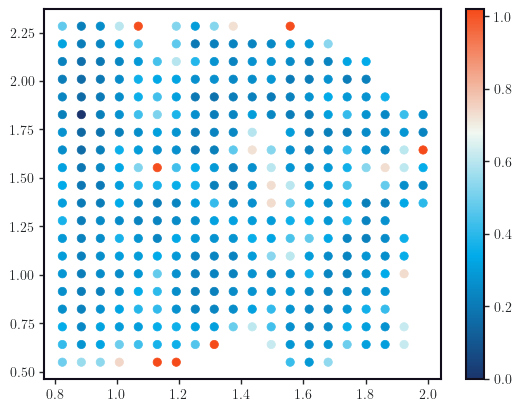

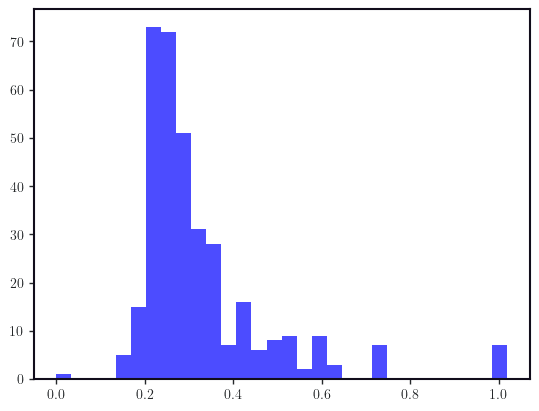

In [36]:
plt.scatter(centers_to_use[:, 0], centers_to_use[:, 1], c=results["df_i"], cmap=rotskoff_cmap)
plt.colorbar()
plt.show()

plt.hist(results["df_i"], bins=30, color='blue', alpha=0.7)
plt.show()